In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)
from imblearn.over_sampling import SMOTE
import joblib

In [5]:
df = pd.read_csv("ecommerce_cleaned.csv")
print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (10000, 30)


,Order_ID,Order_Date,Year,Month,Quarter,Season,Customer_ID,Customer_Gender,Customer_Segment,Region,...,Profit_Margin_%,Shipping_Cost,Shipping_Method,Shipping_Days,Payment_Method,Order_Status,Order_DayOfWeek,Is_Loss,Revenue_Per_Unit,Discount_Category
0,ORD-000001,2023-01-18,2023,1,Q1,Winter,CUST-02791,Male,New,North America,...,32.91,2.25,Economy,4,Google Pay,Delivered,2,0,520.400000,No Discount
1,ORD-000002,2023-11-13,2023,11,Q4,Fall,CUST-02763,Female,Regular,North America,...,16.41,4.72,Economy,5,Credit Card,Delivered,0,0,16.940000,High (21-30%)
2,ORD-000003,2022-04-28,2022,4,Q2,Spring,CUST-05729,Male,Regular,North America,...,33.11,13.28,Standard,8,Credit Card,Processing,3,0,241.300000,No Discount
3,ORD-000004,2021-10-22,2021,10,Q4,Fall,CUST-06490,Female,Regular,Asia,...,43.60,31.11,Express,16,Google Pay,Processing,4,0,130.900000,No Discount
4,ORD-000005,2023-08-06,2023,8,Q3,Summer,CUST-07594,Female,Premium,Europe,...,33.63,8.44,Standard,5,Debit Card,Delivered,6,0,59.606667,Medium (11-20%)


In [6]:
DROP_COLS = ['Is_Loss', 'Order_ID', 'Customer_ID', 'Order_Date',
             'Product_Name', 'Order_DayOfWeek', 'Discount_Category']

X = df.drop(columns=[c for c in DROP_COLS if c in df.columns])
X = X.select_dtypes(include=[np.number])
y = df['Is_Loss']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print(f"Train: {X_train.shape[0]} | Test: {X_test.shape[0]}")

Train: 8000 | Test: 2000


CLASS DISTRIBUTION ANALYSIS
Full dataset y:
Is_Loss
0    8662
1    1338
Name: count, dtype: int64
Imbalance ratio: 8662 : 1338

Training set y_train:
Is_Loss
0    6930
1    1070
Name: count, dtype: int64
Minority class: 13.4% of training data


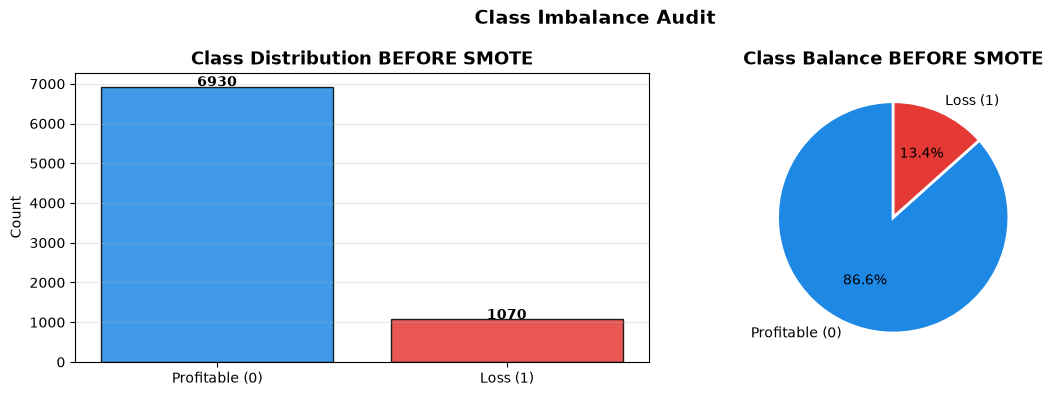

In [7]:
print("CLASS DISTRIBUTION ANALYSIS")
print("=" * 45)
print("Full dataset y:")
print(y.value_counts())
print(f"Imbalance ratio: {y.value_counts()[0]} : {y.value_counts()[1]}")
print()
print("Training set y_train:")
print(y_train.value_counts())
print(f"Minority class: {y_train.value_counts()[1]/len(y_train)*100:.1f}% of training data")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
colors = ['#1E88E5', '#E53935']

axes[0].bar(['Profitable (0)', 'Loss (1)'], y_train.value_counts().values,
            color=colors, edgecolor='black', alpha=0.85)
axes[0].set_title('Class Distribution BEFORE SMOTE', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(y_train.value_counts().values):
    axes[0].text(i, v + 10, str(v), ha='center', fontweight='bold')
axes[0].grid(alpha=0.3, axis='y')

axes[1].pie(y_train.value_counts().values,
            labels=['Profitable (0)', 'Loss (1)'],
            autopct='%1.1f%%', colors=colors,
            startangle=90, wedgeprops={'edgecolor':'white','linewidth':2})
axes[1].set_title('Class Balance BEFORE SMOTE', fontsize=13, fontweight='bold')

plt.suptitle('Class Imbalance Audit', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('class_imbalance_before.png', dpi=150, bbox_inches='tight')
plt.show()

SMOTE Applied!
Before SMOTE -> X_train shape: (8000, 12)
After  SMOTE -> X_train shape: (13860, 12)

Class distribution AFTER SMOTE:
Is_Loss
0    6930
1    6930
Name: count, dtype: int64
Now perfectly balanced: 50% / 50%


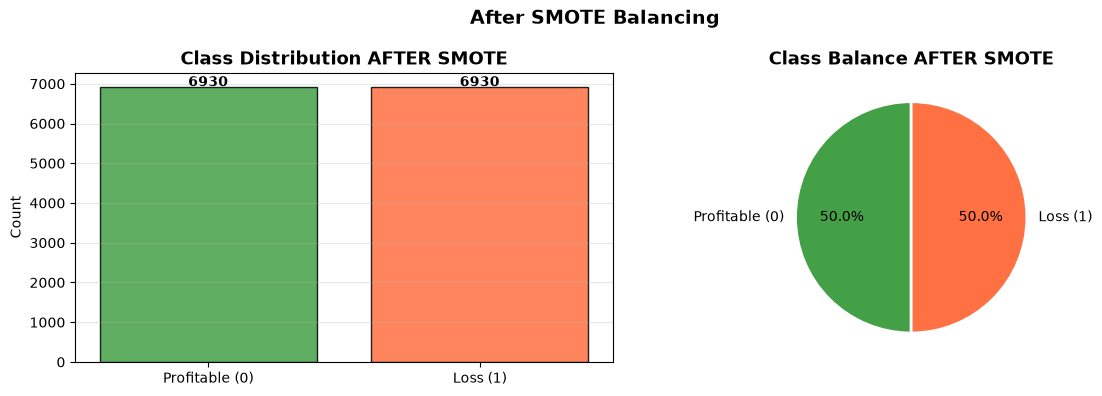

In [8]:
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("SMOTE Applied!")
print(f"Before SMOTE -> X_train shape: {X_train.shape}")
print(f"After  SMOTE -> X_train shape: {X_train_smote.shape}")
print()
print("Class distribution AFTER SMOTE:")
print(pd.Series(y_train_smote).value_counts())
print(f"Now perfectly balanced: 50% / 50%")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
after_counts = pd.Series(y_train_smote).value_counts()

axes[0].bar(['Profitable (0)', 'Loss (1)'], after_counts.values,
            color=['#43A047', '#FF7043'], edgecolor='black', alpha=0.85)
axes[0].set_title('Class Distribution AFTER SMOTE', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(after_counts.values):
    axes[0].text(i, v + 10, str(v), ha='center', fontweight='bold')
axes[0].grid(alpha=0.3, axis='y')

axes[1].pie(after_counts.values,
            labels=['Profitable (0)', 'Loss (1)'],
            autopct='%1.1f%%', colors=['#43A047','#FF7043'],
            startangle=90, wedgeprops={'edgecolor':'white','linewidth':2})
axes[1].set_title('Class Balance AFTER SMOTE', fontsize=13, fontweight='bold')

plt.suptitle('After SMOTE Balancing', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('class_balance_after.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
pre_smote_model = RandomForestClassifier(
    n_estimators=100, max_depth=10, min_samples_split=2,
    random_state=42, n_jobs=-1
)
pre_smote_model.fit(X_train, y_train)
pre_pred = pre_smote_model.predict(X_test)

pre_f1   = f1_score(y_test, pre_pred)
pre_acc  = accuracy_score(y_test, pre_pred)
pre_prec = precision_score(y_test, pre_pred)
pre_rec  = recall_score(y_test, pre_pred)

print("PRE-SMOTE MODEL RESULTS")
print("=" * 40)
print(f"Accuracy  : {pre_acc*100:.2f}%")
print(f"Precision : {pre_prec:.4f}")
print(f"Recall    : {pre_rec:.4f}")
print(f"F1-Score  : {pre_f1:.4f}")

PRE-SMOTE MODEL RESULTS
Accuracy  : 100.00%
Precision : 1.0000
Recall    : 1.0000
F1-Score  : 1.0000


In [10]:
post_smote_model = RandomForestClassifier(
    n_estimators=100, max_depth=10, min_samples_split=2,
    random_state=42, n_jobs=-1
)
post_smote_model.fit(X_train_smote, y_train_smote)
post_pred = post_smote_model.predict(X_test)

post_f1   = f1_score(y_test, post_pred)
post_acc  = accuracy_score(y_test, post_pred)
post_prec = precision_score(y_test, post_pred)
post_rec  = recall_score(y_test, post_pred)

print("POST-SMOTE MODEL RESULTS")
print("=" * 40)
print(f"Accuracy  : {post_acc*100:.2f}%")
print(f"Precision : {post_prec:.4f}")
print(f"Recall    : {post_rec:.4f}")
print(f"F1-Score  : {post_f1:.4f}")

POST-SMOTE MODEL RESULTS
Accuracy  : 100.00%
Precision : 1.0000
Recall    : 1.0000
F1-Score  : 1.0000


In [11]:
print("PRE-SMOTE Classification Report")
print("=" * 50)
print(classification_report(y_test, pre_pred, target_names=['Profitable', 'Loss']))

print("POST-SMOTE Classification Report")
print("=" * 50)
print(classification_report(y_test, post_pred, target_names=['Profitable', 'Loss']))

PRE-SMOTE Classification Report
              precision    recall  f1-score   support

  Profitable       1.00      1.00      1.00      1732
        Loss       1.00      1.00      1.00       268

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000

POST-SMOTE Classification Report
              precision    recall  f1-score   support

  Profitable       1.00      1.00      1.00      1732
        Loss       1.00      1.00      1.00       268

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



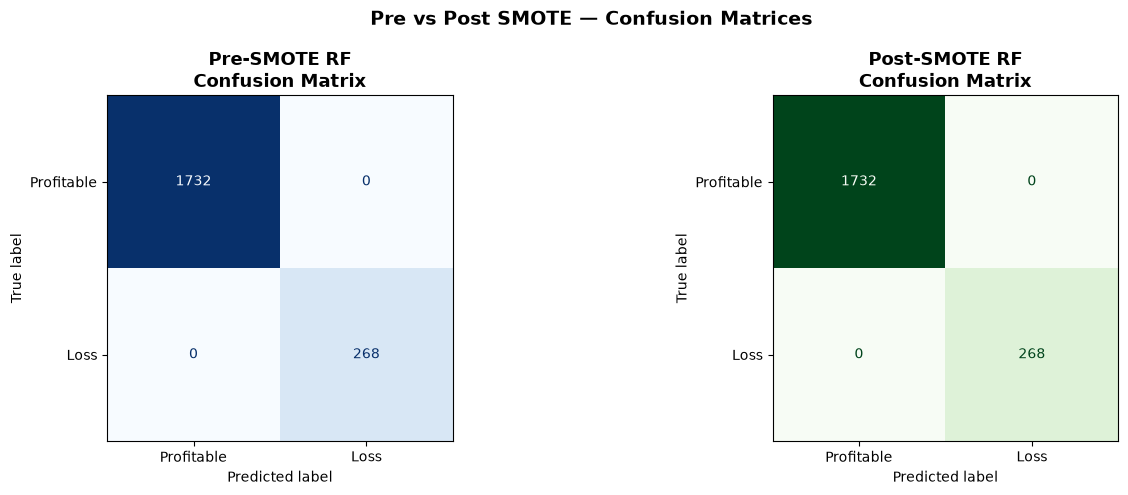

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ConfusionMatrixDisplay(confusion_matrix(y_test, pre_pred),
                       display_labels=['Profitable','Loss']).plot(
    ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Pre-SMOTE RF\nConfusion Matrix', fontsize=13, fontweight='bold')

ConfusionMatrixDisplay(confusion_matrix(y_test, post_pred),
                       display_labels=['Profitable','Loss']).plot(
    ax=axes[1], colorbar=False, cmap='Greens')
axes[1].set_title('Post-SMOTE RF\nConfusion Matrix', fontsize=13, fontweight='bold')

plt.suptitle('Pre vs Post SMOTE — Confusion Matrices', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_smote_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

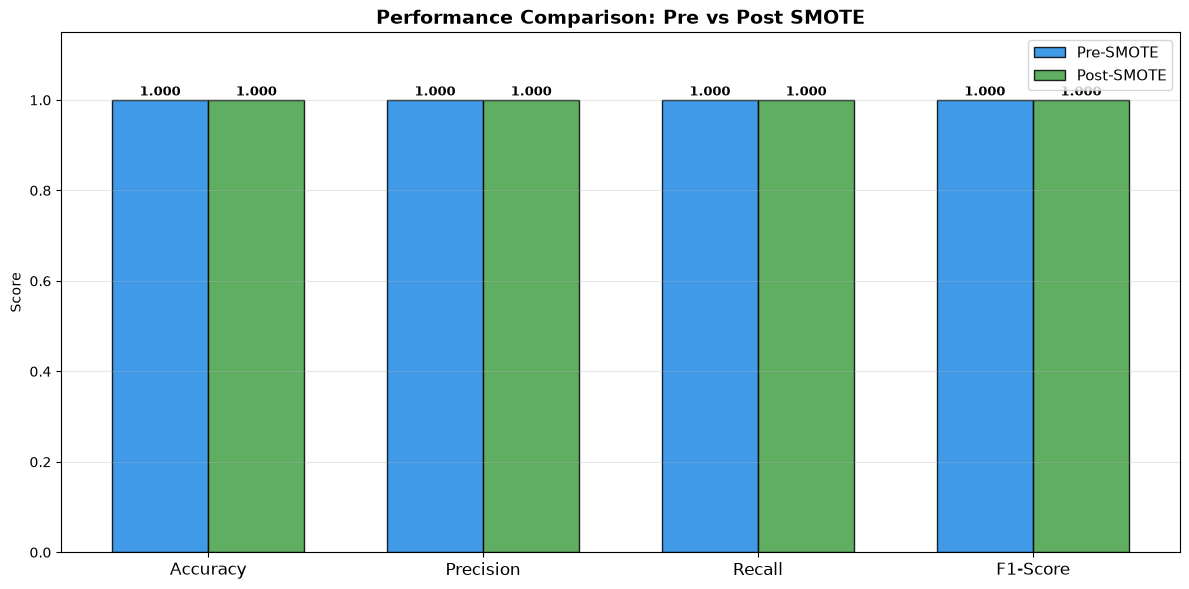

In [13]:

metrics  = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
pre_s    = [pre_acc, pre_prec, pre_rec, pre_f1]
post_s   = [post_acc, post_prec, post_rec, post_f1]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width/2, pre_s, width, label='Pre-SMOTE',
               color='#1E88E5', edgecolor='black', alpha=0.85)
bars2 = ax.bar(x + width/2, post_s, width, label='Post-SMOTE',
               color='#43A047', edgecolor='black', alpha=0.85)

ax.set_title('Performance Comparison: Pre vs Post SMOTE', fontsize=14, fontweight='bold')
ax.set_ylabel('Score')
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=12)
ax.set_ylim(0, 1.15)
ax.legend(fontsize=11)
ax.grid(alpha=0.3, axis='y')

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', fontsize=9, fontweight='bold')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('pre_post_smote_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

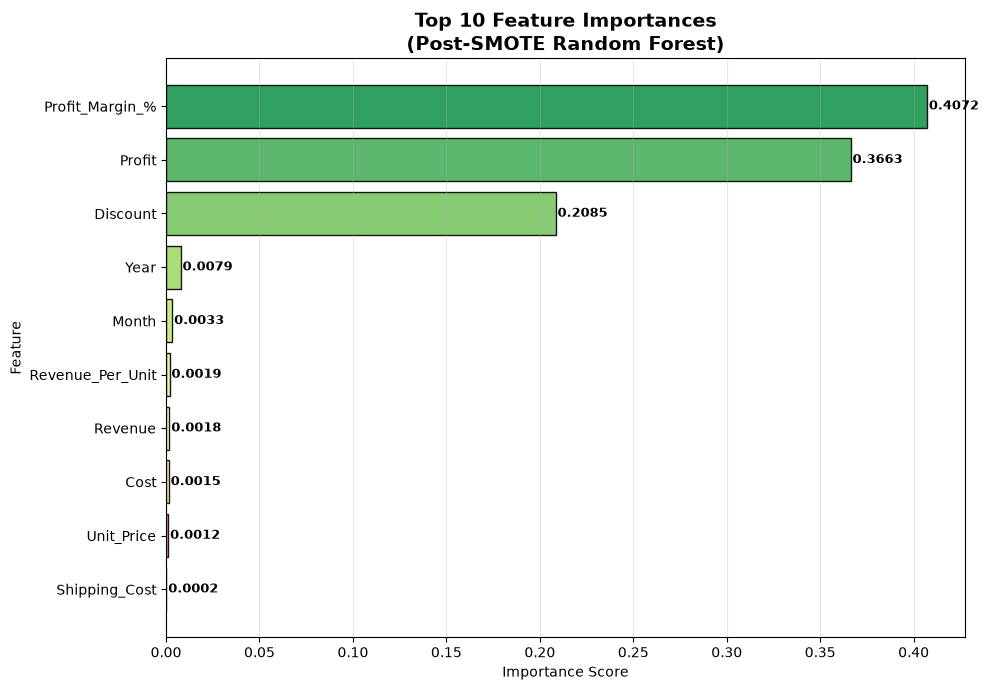

Top 10 Features:
         Feature  Importance
 Profit_Margin_%    0.407154
          Profit    0.366311
        Discount    0.208478
            Year    0.007857
           Month    0.003337
Revenue_Per_Unit    0.001901
         Revenue    0.001823
            Cost    0.001498
      Unit_Price    0.001188
   Shipping_Cost    0.000200


In [14]:
feat_imp = pd.DataFrame({
    'Feature'   : X.columns,
    'Importance': post_smote_model.feature_importances_
}).sort_values('Importance', ascending=True).tail(10)

plt.figure(figsize=(10, 7))
colors = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(feat_imp)))
bars = plt.barh(feat_imp['Feature'], feat_imp['Importance'],
                color=colors, edgecolor='black', alpha=0.9)
plt.title('Top 10 Feature Importances\n(Post-SMOTE Random Forest)',
          fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
for bar, val in zip(bars, feat_imp['Importance']):
    plt.text(val + 0.001, bar.get_y() + bar.get_height()/2,
             f'{val:.4f}', va='center', fontsize=9, fontweight='bold')
plt.grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig('feature_importance_top10.png', dpi=150, bbox_inches='tight')
plt.show()

print("Top 10 Features:")
print(feat_imp[::-1].to_string(index=False))

In [15]:

top_features = feat_imp[::-1]['Feature'].tolist()

print("BUSINESS INTERPRETATION — Feature Importance")
print("=" * 60)
print(f"Top 3 drivers of Loss prediction:")
for i, feat in enumerate(top_features[:3], 1):
    imp = feat_imp[feat_imp['Feature']==feat]['Importance'].values[0]
    print(f"  {i}. {feat} (importance: {imp:.4f})")

print()
print("What this means for the business:")
print("  - The model primarily uses financial metrics (Revenue,")
print("    Cost, Profit) to detect loss-making orders.")
print("  - High Discount and low Profit_Margin are strong signals")
print("    that an order will result in a loss.")
print("  - Shipping Cost also plays a role — expensive shipping")
print("    on low-margin orders triggers loss prediction.")
print()
print("Actionable Insight:")
print("  Orders with Discount > 20% AND Shipping_Cost > avg")
print("  should trigger a pricing review before confirmation.")

BUSINESS INTERPRETATION — Feature Importance
Top 3 drivers of Loss prediction:
  1. Profit_Margin_% (importance: 0.4072)
  2. Profit (importance: 0.3663)
  3. Discount (importance: 0.2085)

What this means for the business:
  - The model primarily uses financial metrics (Revenue,
    Cost, Profit) to detect loss-making orders.
  - High Discount and low Profit_Margin are strong signals
    that an order will result in a loss.
  - Shipping Cost also plays a role — expensive shipping
    on low-margin orders triggers loss prediction.

Actionable Insight:
  Orders with Discount > 20% AND Shipping_Cost > avg
  should trigger a pricing review before confirmation.


In [16]:

joblib.dump(post_smote_model, 'production_rf_model.pkl')
import os
size = os.path.getsize('production_rf_model.pkl') / 1024
print(f"Production model saved: production_rf_model.pkl ({size:.1f} KB)")

verify = joblib.load('production_rf_model.pkl')
print(f"Verification F1: {f1_score(y_test, verify.predict(X_test)):.4f}")

Production model saved: production_rf_model.pkl (150.9 KB)
Verification F1: 1.0000


In [17]:

print("=" * 55)
print("FINAL SUMMARY")
print("=" * 55)
print(f"{'Metric':<20} {'Pre-SMOTE':>15} {'Post-SMOTE':>15}")
print("-" * 55)
print(f"{'Accuracy':<20} {pre_acc*100:>14.2f}% {post_acc*100:>14.2f}%")
print(f"{'Precision':<20} {pre_prec:>15.4f} {post_prec:>15.4f}")
print(f"{'Recall':<20} {pre_rec:>15.4f} {post_rec:>15.4f}")
print(f"{'F1-Score':<20} {pre_f1:>15.4f} {post_f1:>15.4f}")
print("=" * 55)
print()
print("KEY RULES FOLLOWED:")
print("  SMOTE applied ONLY to X_train/y_train")
print("  X_test/y_test kept completely untouched")
print("  Model tested on real data only (no synthetic)")
print("  Production model saved: production_rf_model.pkl")

FINAL SUMMARY
Metric                     Pre-SMOTE      Post-SMOTE
-------------------------------------------------------
Accuracy                     100.00%         100.00%
Precision                     1.0000          1.0000
Recall                        1.0000          1.0000
F1-Score                      1.0000          1.0000

KEY RULES FOLLOWED:
  SMOTE applied ONLY to X_train/y_train
  X_test/y_test kept completely untouched
  Model tested on real data only (no synthetic)
  Production model saved: production_rf_model.pkl
